# 1) Data Loading

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Setup Transforms
# MNIST images are grayscale (1 channel), so we use a single mean and std for normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

# 2. Download and Load Dataset
# This will automatically download the 60,000 images and their labels into './data'
mnist_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    transform=transform, 
    download=True
)

# 3. Setup DataLoader
batch_size = 128
dataloader = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True)

print("✅ Dataset loaded successfully!")
print(f"Total number of images: {len(mnist_dataset)}")

# 4. Quick Sanity Check (Fetch one batch)
images, labels = next(iter(dataloader))
print(f"Images batch shape: {images.shape}  # (Batch_Size, Channels, Height, Width)")
print(f"Labels batch shape: {labels.shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 124MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 11.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 83.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]


✅ Dataset loaded successfully!
Total number of images: 60000
Images batch shape: torch.Size([128, 1, 28, 28])  # (Batch_Size, Channels, Height, Width)
Labels batch shape: torch.Size([128])


# 2) Define the CGAN Architecture (Generator & Discriminator)

In [2]:
import torch
import torch.nn as nn

# ==========================================
# 1. The Generator (The Artist)
# ==========================================
class Generator(nn.Module):
    def __init__(self, noise_dim, num_classes):
        super(Generator, self).__init__()
        
        # Embed the label (0-9) into a vector of the same size
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        
        # Total input dimension = noise + label
        input_dim = noise_dim + num_classes
        
        self.model = nn.Sequential(
            # Input: (input_dim) x 1 x 1. 
            # Output: 256 channels, 7x7 spatial size
            nn.ConvTranspose2d(input_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # Input: 256 x 7 x 7. 
            # Output: 128 channels, 14x14 spatial size
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # Input: 128 x 14 x 14. 
            # Output: 1 channel (Grayscale), 28x28 spatial size
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh() # Scales output to [-1, 1]
        )

    def forward(self, noise, labels):
        # Reshape label and noise to be 1x1 spatial dimensions (Channels)
        c = self.label_embedding(labels).unsqueeze(2).unsqueeze(3) 
        z = noise.unsqueeze(2).unsqueeze(3) 
        
        # Concatenate along the channel dimension
        x = torch.cat([z, c], dim=1) 
        return self.model(x)

# ==========================================
# 2. The Discriminator (The Art Critic)
# ==========================================
class Discriminator(nn.Module):
    def __init__(self, num_classes):
        super(Discriminator, self).__init__()
        
        # Embed the label into a full 28x28 image channel
        self.label_embedding = nn.Embedding(num_classes, 28 * 28)
        
        self.model = nn.Sequential(
            # Input: 1 channel (Image) + 1 channel (Label) = 2 channels, 28x28
            # Output: 64 channels, 14x14
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Input: 64 x 14 x 14. 
            # Output: 128 channels, 7x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Input: 128 x 7 x 7. 
            # Output: 1 channel, 1x1 (A single scalar value)
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False),
            nn.Sigmoid() # Converts the final score to a probability [0, 1]
        )

    def forward(self, img, labels):
        # Reshape the embedded label to match the image dimensions (Batch, 1, 28, 28)
        c = self.label_embedding(labels).view(-1, 1, 28, 28)
        
        # Concatenate the image and the label channel
        x = torch.cat([img, c], dim=1)
        return self.model(x).view(-1, 1).squeeze(1)

# ==========================================
# 3. Model Initialization & Testing
# ==========================================
NOISE_DIM = 100
NUM_CLASSES = 10 # Digits from 0 to 9

generator = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
discriminator = Discriminator(num_classes=NUM_CLASSES)

print("✅ CGAN Architecture built successfully for 28x28 MNIST images!")

✅ CGAN Architecture built successfully for 28x28 MNIST images!


# 3) Loss Function, Optimizers, and The Training Loop

In [3]:
import torch.optim as optim

# ==========================================
# 1. Setup Loss Function and Optimizers
# ==========================================
# Binary Cross Entropy Loss to calculate the error (0 or 1)
criterion = nn.BCELoss() 

# Standard Adam optimizer hyperparameters for DCGANs
lr = 0.0002
beta1 = 0.5

# Setup Optimizers for both Generator and Discriminator
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Move all models and loss function to GPU for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator.to(device)
discriminator.to(device)
criterion.to(device)

print(f"🔥 Starting Training on: {device}")

# ==========================================
# 2. The Training Loop
# ==========================================
num_epochs = 20 

print("⚔️ Let the battle begin between the Generator and Discriminator!")

for epoch in range(num_epochs):
    for i, (real_imgs, labels) in enumerate(dataloader):
        
        batch_size = real_imgs.size(0)
        
        # Move real images and labels to GPU
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        
        # Create Ground Truth Targets (1 for Real, 0 for Fake)
        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)
        
        # ------------------------------------------
        # A. Train Discriminator (The Critic)
        # ------------------------------------------
        optimizer_D.zero_grad() 
        
        # 1. Train with Real Images (Should predict 1)
        outputs_real = discriminator(real_imgs, labels)
        d_loss_real = criterion(outputs_real, real_targets)
        
        # 2. Train with Fake Images (Should predict 0)
        noise = torch.randn(batch_size, NOISE_DIM, device=device)
        fake_imgs = generator(noise, labels)
        
        # Use .detach() to avoid training the Generator in this step
        outputs_fake = discriminator(fake_imgs.detach(), labels) 
        d_loss_fake = criterion(outputs_fake, fake_targets)
        
        # 3. Calculate total loss and update weights
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # ------------------------------------------
        # B. Train Generator (The Artist)
        # ------------------------------------------
        optimizer_G.zero_grad()
        
        # The Generator tries to fool the Discriminator 
        # (It wants the Discriminator to output 1 for its fake images)
        outputs = discriminator(fake_imgs, labels)
        g_loss = criterion(outputs, real_targets)
        
        # Calculate loss and update Generator weights
        g_loss.backward()
        optimizer_G.step()
        
    # Print the training progress at the end of each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

print("🎉 Training Complete!")

🔥 Starting Training on: cuda
⚔️ Let the battle begin between the Generator and Discriminator!
Epoch [1/20] | D Loss: 1.2610 | G Loss: 0.7452
Epoch [2/20] | D Loss: 1.0881 | G Loss: 0.9851
Epoch [3/20] | D Loss: 1.1145 | G Loss: 0.8434
Epoch [4/20] | D Loss: 1.1525 | G Loss: 0.9717
Epoch [5/20] | D Loss: 1.3084 | G Loss: 0.5522
Epoch [6/20] | D Loss: 1.3033 | G Loss: 1.1034
Epoch [7/20] | D Loss: 1.2529 | G Loss: 0.7553
Epoch [8/20] | D Loss: 1.3609 | G Loss: 0.5582
Epoch [9/20] | D Loss: 1.3139 | G Loss: 0.7031
Epoch [10/20] | D Loss: 1.3004 | G Loss: 0.8100
Epoch [11/20] | D Loss: 1.3170 | G Loss: 0.8853
Epoch [12/20] | D Loss: 1.3328 | G Loss: 0.7193
Epoch [13/20] | D Loss: 1.2751 | G Loss: 0.8639
Epoch [14/20] | D Loss: 1.3573 | G Loss: 0.8949
Epoch [15/20] | D Loss: 1.3639 | G Loss: 1.1145
Epoch [16/20] | D Loss: 1.3854 | G Loss: 0.6304
Epoch [17/20] | D Loss: 1.3572 | G Loss: 1.0843
Epoch [18/20] | D Loss: 1.3297 | G Loss: 1.0887
Epoch [19/20] | D Loss: 1.3344 | G Loss: 0.7781
Epo

# 4) Inference and Visualization

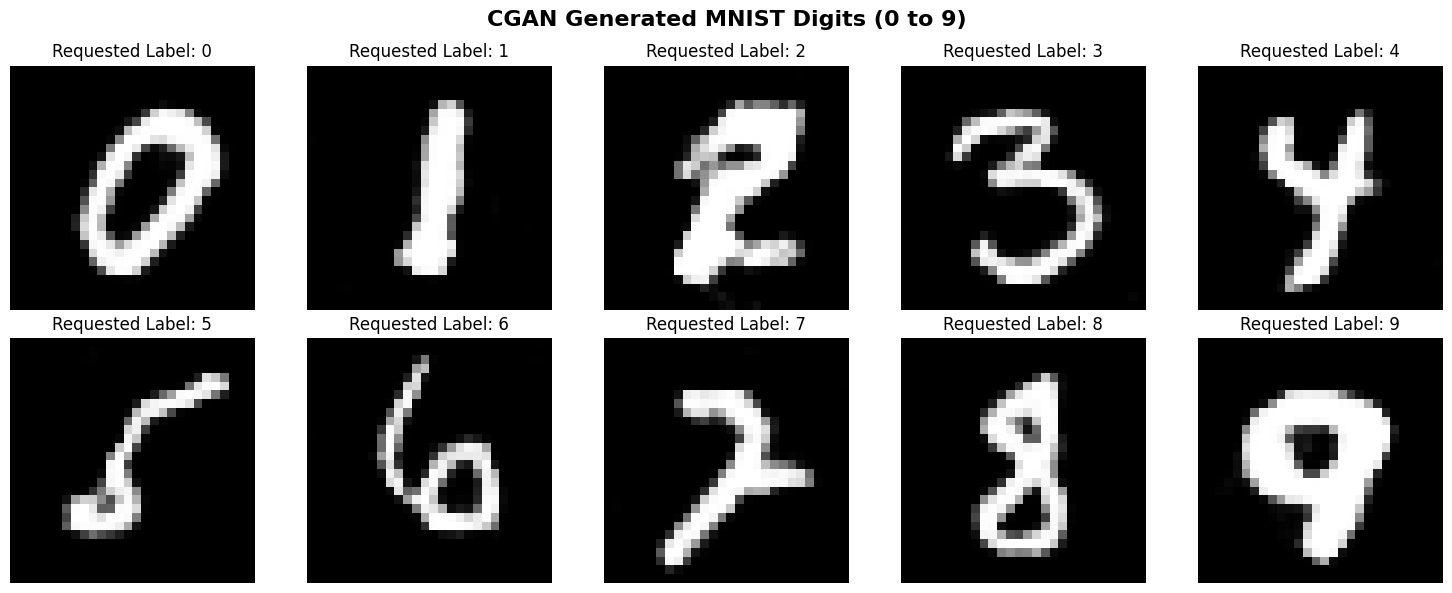

In [4]:
import matplotlib.pyplot as plt

# 1. Set Generator to evaluation mode (important for BatchNorm layers)
generator.eval()

# 2. We want to generate 10 images, one for each digit from 0 to 9
num_samples = 10
# Create a tensor with labels [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
test_labels = torch.arange(num_samples, dtype=torch.long, device=device)

# 3. Generate random pure noise
test_noise = torch.randn(num_samples, NOISE_DIM, device=device)

# 4. Generate images (turn off gradients to save memory and speed up)
with torch.no_grad():
    generated_imgs = generator(test_noise, test_labels).cpu()

# 5. Denormalize images from [-1, 1] back to [0, 1] for matplotlib
generated_imgs = (generated_imgs + 1) / 2

# 6. Plot the generated digits
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('CGAN Generated MNIST Digits (0 to 9)', fontsize=16, fontweight='bold')

axes = axes.flatten()
for i in range(num_samples):
    # Remove the channel dimension (1, 28, 28) -> (28, 28) for grayscale plotting
    img = generated_imgs[i].squeeze().numpy()
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Requested Label: {test_labels[i].item()}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 5) (Updated): Training Loop with GIF Generation

In [5]:
import torch.optim as optim
import torchvision.utils as vutils
import imageio
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Loss Function and Optimizers
# ==========================================
criterion = nn.BCELoss() 
lr = 0.0002
beta1 = 0.5

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator.to(device)
discriminator.to(device)
criterion.to(device)

# ==========================================
# 2. 🌟 NEW: Setup Fixed Noise for the GIF
# ==========================================
# Create fixed noise and labels (0 to 9) to see how the Generator improves on the EXACT SAME input
fixed_noise = torch.randn(10, NOISE_DIM, device=device)
fixed_labels = torch.arange(10, dtype=torch.long, device=device)
img_list = [] # List to store generated frames

# ==========================================
# 3. The Training Loop
# ==========================================
num_epochs = 20 

print(f"🔥 Starting Training on: {device}")
print("⚔️ Let the battle begin! (Tracking progress for GIF...)")

for epoch in range(num_epochs):
    for i, (real_imgs, labels) in enumerate(dataloader):
        
        batch_size = real_imgs.size(0)
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        
        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)
        
        # --- A. Train Discriminator ---
        optimizer_D.zero_grad() 
        outputs_real = discriminator(real_imgs, labels)
        d_loss_real = criterion(outputs_real, real_targets)
        
        noise = torch.randn(batch_size, NOISE_DIM, device=device)
        fake_imgs = generator(noise, labels)
        
        outputs_fake = discriminator(fake_imgs.detach(), labels) 
        d_loss_fake = criterion(outputs_fake, fake_targets)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # --- B. Train Generator ---
        optimizer_G.zero_grad()
        outputs = discriminator(fake_imgs, labels)
        g_loss = criterion(outputs, real_targets)
        
        g_loss.backward()
        optimizer_G.step()
        
    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")
    
    # ==========================================
    # 4. 🌟 NEW: Capture Frame for GIF at the end of each Epoch
    # ==========================================
    with torch.no_grad():
        generator.eval() # Switch to evaluation mode
        fake = generator(fixed_noise, fixed_labels).cpu()
        generator.train() # Switch back to training mode
        
        # Arrange the 10 generated images in a single row (grid)
        grid = vutils.make_grid(fake, nrow=10, normalize=True)
        # Convert PyTorch tensor (C, H, W) to Numpy Array (H, W, C) for ImageIO
        img_list.append(np.transpose(grid.numpy(), (1, 2, 0)))

print("🎉 Training Complete!")

# ==========================================
# 5. 🌟 NEW: Compile and Save the GIF
# ==========================================
print("🎬 Compiling the GIF...")
# Convert pixel values to standard 0-255 format (uint8)
img_list_uint8 = [(img * 255).astype(np.uint8) for img in img_list]

# Save the frames as a GIF (fps=2 means 2 frames per second)
imageio.mimsave('cgan_training_progress.gif', img_list_uint8, fps=2)
print("✅ GIF saved successfully as 'cgan_training_progress.gif'!")

🔥 Starting Training on: cuda
⚔️ Let the battle begin! (Tracking progress for GIF...)
Epoch [1/20] | D Loss: 1.3387 | G Loss: 1.0423
Epoch [2/20] | D Loss: 1.3510 | G Loss: 0.6438
Epoch [3/20] | D Loss: 1.3827 | G Loss: 0.9034
Epoch [4/20] | D Loss: 1.2575 | G Loss: 0.9612
Epoch [5/20] | D Loss: 1.2524 | G Loss: 0.8624
Epoch [6/20] | D Loss: 1.3213 | G Loss: 1.0569
Epoch [7/20] | D Loss: 1.3254 | G Loss: 1.1723
Epoch [8/20] | D Loss: 1.3913 | G Loss: 1.1171
Epoch [9/20] | D Loss: 1.2899 | G Loss: 0.8544
Epoch [10/20] | D Loss: 1.2699 | G Loss: 0.9316
Epoch [11/20] | D Loss: 1.2253 | G Loss: 0.9907
Epoch [12/20] | D Loss: 1.3247 | G Loss: 0.6669
Epoch [13/20] | D Loss: 1.3401 | G Loss: 1.0683
Epoch [14/20] | D Loss: 1.3997 | G Loss: 0.4984
Epoch [15/20] | D Loss: 1.3349 | G Loss: 1.1109
Epoch [16/20] | D Loss: 1.1733 | G Loss: 1.1895
Epoch [17/20] | D Loss: 1.2004 | G Loss: 0.9583
Epoch [18/20] | D Loss: 1.2113 | G Loss: 1.0163
Epoch [19/20] | D Loss: 1.2342 | G Loss: 1.0277
Epoch [20/20

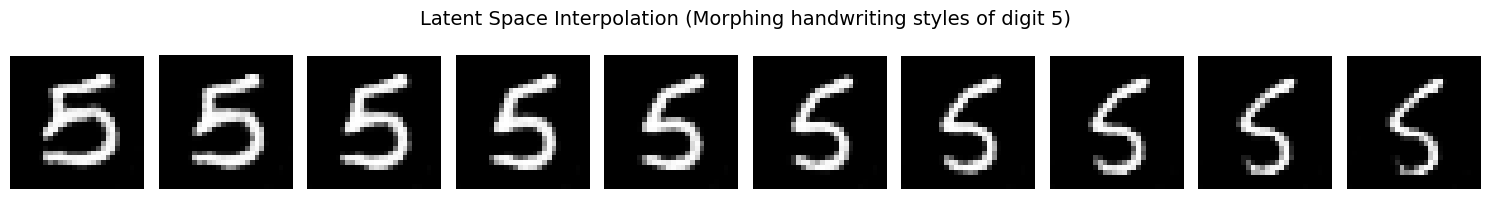

In [6]:
import numpy as np

# 1. Set the target digit we want to morph (e.g., the digit 5)
target_label = torch.tensor([5], device=device)

# 2. Create two completely different random noise vectors (z1 and z2)
z1 = torch.randn(1, NOISE_DIM, device=device)
z2 = torch.randn(1, NOISE_DIM, device=device)

# 3. Create 10 intermediate steps between z1 and z2 using linear interpolation
num_steps = 10
alphas = np.linspace(0, 1, num_steps)

interpolated_images = []

generator.eval()
with torch.no_grad():
    for alpha in alphas:
        # Mix the two noise vectors mathematically
        z_mixed = (1 - alpha) * z1 + alpha * z2
        
        # Generate the image from the mixed noise
        img = generator(z_mixed, target_label).cpu()
        img = (img + 1) / 2 # Denormalize
        interpolated_images.append(img.squeeze().numpy())

# 4. Plot the smooth transition
fig, axes = plt.subplots(1, num_steps, figsize=(15, 2))
fig.suptitle('Latent Space Interpolation (Morphing handwriting styles of digit 5)', fontsize=14)

for i in range(num_steps):
    axes[i].imshow(interpolated_images[i], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
import torch.optim as optim
import torchvision.utils as vutils
import imageio
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 🌟 RESET THE MODELS (فرمتة مخ المولد والمميز)
# ==========================================
# Re-initialize them to start from scratch (pure noise)
generator = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES).to(device)
discriminator = Discriminator(num_classes=NUM_CLASSES).to(device)

criterion = nn.BCELoss().to(device)
lr = 0.0002
beta1 = 0.5
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# ==========================================
# 2. Setup Fixed Noise for the GIF
# ==========================================
fixed_noise = torch.randn(10, NOISE_DIM, device=device)
fixed_labels = torch.arange(10, dtype=torch.long, device=device)
img_list = [] 

# ==========================================
# 3. 🌟 CAPTURE FRAME 0 (Untrained State - Pure Noise)
# ==========================================
print("📸 Capturing initial untrained state (Noise)...")
with torch.no_grad():
    generator.eval()
    fake_initial = generator(fixed_noise, fixed_labels).cpu()
    grid_initial = vutils.make_grid(fake_initial, nrow=10, normalize=True)
    frame_initial = np.transpose(grid_initial.numpy(), (1, 2, 0))
    
    # هنضيف أول لقطة 3 مرات عشان تثبت في أول الـ GIF وماتختفيش بسرعة
    for _ in range(3):
        img_list.append(frame_initial)
    generator.train()

# ==========================================
# 4. The Training Loop
# ==========================================
num_epochs = 20 
print("⚔️ Let the battle begin! (Tracking progress for GIF...)")

for epoch in range(num_epochs):
    for i, (real_imgs, labels) in enumerate(dataloader):
        
        batch_size = real_imgs.size(0)
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)
        
        # --- Train Discriminator ---
        optimizer_D.zero_grad() 
        outputs_real = discriminator(real_imgs, labels)
        d_loss_real = criterion(outputs_real, real_targets)
        
        noise = torch.randn(batch_size, NOISE_DIM, device=device)
        fake_imgs = generator(noise, labels)
        
        outputs_fake = discriminator(fake_imgs.detach(), labels) 
        d_loss_fake = criterion(outputs_fake, fake_targets)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # --- Train Generator ---
        optimizer_G.zero_grad()
        outputs = discriminator(fake_imgs, labels)
        g_loss = criterion(outputs, real_targets)
        
        g_loss.backward()
        optimizer_G.step()
        
    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")
    
    # Capture Frame for GIF at the end of each Epoch
    with torch.no_grad():
        generator.eval()
        fake = generator(fixed_noise, fixed_labels).cpu()
        grid = vutils.make_grid(fake, nrow=10, normalize=True)
        img_list.append(np.transpose(grid.numpy(), (1, 2, 0)))
        generator.train()

print("🎉 Training Complete!")

# ==========================================
# 5. Compile and Save the GIF
# ==========================================
print("🎬 Compiling the GIF...")
# Duplicate the very last frame 3 times so the GIF pauses on the final perfect numbers
for _ in range(2):
    img_list.append(img_list[-1])
    
img_list_uint8 = [(img * 255).astype(np.uint8) for img in img_list]
imageio.mimsave('cgan_training_progress_v2.gif', img_list_uint8, fps=3)
print("✅ New GIF saved successfully as 'cgan_training_progress_v2.gif'!")

📸 Capturing initial untrained state (Noise)...
⚔️ Let the battle begin! (Tracking progress for GIF...)
Epoch [1/20] | D Loss: 1.2475 | G Loss: 0.8310
Epoch [2/20] | D Loss: 1.4163 | G Loss: 1.5116
Epoch [3/20] | D Loss: 1.2591 | G Loss: 1.2590
Epoch [4/20] | D Loss: 1.2731 | G Loss: 0.5721
Epoch [5/20] | D Loss: 1.2906 | G Loss: 0.6501
Epoch [6/20] | D Loss: 1.3434 | G Loss: 1.0452
Epoch [7/20] | D Loss: 1.3248 | G Loss: 1.1673
Epoch [8/20] | D Loss: 1.3156 | G Loss: 1.0164
Epoch [9/20] | D Loss: 1.3394 | G Loss: 0.9757
Epoch [10/20] | D Loss: 1.3640 | G Loss: 0.8852
Epoch [11/20] | D Loss: 1.3353 | G Loss: 0.7417
Epoch [12/20] | D Loss: 1.2809 | G Loss: 0.8681
Epoch [13/20] | D Loss: 1.3130 | G Loss: 0.7588
Epoch [14/20] | D Loss: 1.2768 | G Loss: 0.9678
Epoch [15/20] | D Loss: 1.3166 | G Loss: 0.7560
Epoch [16/20] | D Loss: 1.3566 | G Loss: 0.5801
Epoch [17/20] | D Loss: 1.3020 | G Loss: 1.0155
Epoch [18/20] | D Loss: 1.3365 | G Loss: 0.9415
Epoch [19/20] | D Loss: 1.3161 | G Loss: 0